[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/openquantumhardware/qick/blob/merge-hrl-main/emulator/notebooks/tutorial/02_Parameter_Sweeps_emu.ipynb)

# 02 - Parameter Sweeps with tProc v2 (Emulator Edition)

**Objective:** Learn how to automate parameter variation (sweeps) to create 1D and 2D scans, and understand how to retrieve the actual swept values -- running against the Verilator emulator instead of a physical RFSoC.

This is a 1:1 port of the on-hardware tutorial `02_Parameter_Sweeps.ipynb` (mirrored under [`../../docs/source/tutorials/`](../../docs/source/tutorials/) in this repo). Only Section 1 (connecting to the board) and the size of the 2D sweep in Section 4 are adapted -- see the note there.

## 0. Colab Setup

Skip this cell if you're running locally with the `qick-venv` kernel (see [`emulator/README.md`](https://github.com/openquantumhardware/qick/blob/merge-hrl-main/emulator/README.md)) -- it's a no-op there. In Google Colab it clones this repo, builds Verilator 5.042 from source, and installs the Python dependencies. **First run takes a few minutes** (compiling Verilator); re-running later cells, or reconnecting to the same runtime, reuses what's already built.

In [ ]:
import os
import sys
import pathlib
import subprocess

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


def run(cmd, **kwargs):
    """Run a shell command, streaming output, and raise loudly on failure.

    Using this instead of bare `!command` / get_ipython().system() so a
    failure here stops the bootstrap immediately with a real traceback,
    instead of silently letting later cells fail with a confusing
    ModuleNotFoundError.
    """
    print(f"+ {cmd}")
    result = subprocess.run(cmd, shell=True, **kwargs)
    if result.returncode != 0:
        raise RuntimeError(f"Command failed (rc={result.returncode}): {cmd}")


if IN_COLAB:
    REPO_URL = "https://github.com/openquantumhardware/qick.git"
    REPO_BRANCH = "merge-hrl-main"
    REPO_DIR = pathlib.Path("/content/qick")

    if not REPO_DIR.exists():
        print(f"Cloning {REPO_URL} @ {REPO_BRANCH} ...")
        run(f"git clone --branch {REPO_BRANCH} --depth 1 {REPO_URL} {REPO_DIR}")
    os.chdir(REPO_DIR)

    print("Fetching git submodules (Verilator source, AXI/common_cells) ...")
    run("git submodule update --init --recursive --depth 1")

    def verilator_version():
        try:
            r = subprocess.run(["verilator", "--version"], capture_output=True, text=True)
        except FileNotFoundError:
            return ""
        return r.stdout

    if "5.042" not in verilator_version():
        print("Installing build dependencies (apt) ...")
        run("DEBIAN_FRONTEND=noninteractive apt-get -qq update")
        run(
            "DEBIAN_FRONTEND=noninteractive apt-get -qq install -y "
            "git help2man perl python3 make autoconf g++ flex bison ccache "
            "libgoogle-perftools-dev numactl perl-doc libfl-dev zlib1g-dev"
        )

        print("Building Verilator 5.042 from source (a few minutes, first run only) ...")
        os.chdir(REPO_DIR / "emulator" / "submodules" / "verilator")
        run("autoconf")
        run("./configure")
        run("make -j$(nproc)")
        run("make install")
        os.chdir(REPO_DIR)
        final_version = verilator_version()
        if "5.042" not in final_version:
            raise RuntimeError(
                "Verilator build finished but 'verilator --version' still doesn't "
                f"report 5.042 (got: {final_version!r})"
            )
        print(final_version)
    else:
        print("Verilator 5.042 already installed, skipping build.")

    # Scientific-Python deps only -- NOT jupyter/ipykernel, which would fight
    # with Colab's own kernel runtime. `emulator/requirements.txt` is for the
    # local venv+Jupyter setup (see emulator/README.md); Colab needs a subset.
    print("Installing Python dependencies ...")
    run("pip install numpy scipy matplotlib tqdm")
    run("pip install -e .")

    # Belt-and-suspenders: insert the source dirs directly, so `import qick`
    # works below even if pip's editable-install .pth file isn't picked up by
    # this already-running interpreter (a known Colab quirk).
    for rel in ("qick_lib", "emulator/software"):
        p = str(REPO_DIR / rel)
        if p not in sys.path:
            sys.path.insert(0, p)

    os.chdir(REPO_DIR / "emulator" / "notebooks" / "tutorial")

    # Verify right here, in this cell, instead of letting a failure surface
    # one cell later as a confusing ModuleNotFoundError.
    import importlib
    importlib.invalidate_caches()
    try:
        import qick
        print(f"\nColab setup complete. qick {qick.get_version()} importable from {qick.__file__}")
    except ImportError as e:
        raise RuntimeError(
            f"Setup finished but 'import qick' still fails ({e}). "
            f"cwd={pathlib.Path.cwd()}, REPO_DIR contents: {list(REPO_DIR.iterdir())}"
        ) from e
    print(f"Working directory: {pathlib.Path.cwd()}")
else:
    print("Not running in Colab -- skipping clone/build (using the local checkout as-is).")


## 1. Setup

In [2]:
# Jupyter notebook setup
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import sys
import pathlib
import logging

# Local qick_lib / emulator path setup (see emulator/notebooks/00_intro_emu.ipynb)
REPO_ROOT = pathlib.Path.cwd().parent.parent   # emulator/ (tutorial/ nests one level deeper)
sys.path.insert(0, str(REPO_ROOT / '..' / 'qick_lib'))
sys.path.insert(0, str(REPO_ROOT / 'software'))

import qick
from qick import *
from qick.asm_v2 import AveragerProgramV2, QickSweep1D, QickSpan

# Emulator entry point (drop-in replacement for QickSoc)
from qick_emu import QickEmu

logging.basicConfig(level=logging.INFO, format='%(levelname)-8s [%(filename)s:%(lineno)d] %(message)s')
logging.getLogger("qick_processor").setLevel(logging.WARNING)

# --- No firmware .bit file or physical board needed ---
# On real hardware:
#     BITSTREAM_PATH = '/path/to/your/firmware.bit'
#     soc = QickSoc(BITSTREAM_PATH)
CFG_PATH = REPO_ROOT / 'config' / 'qick_emu_config.json'
soc      = QickEmu(str(CFG_PATH))
soccfg   = soc.soccfg

# Define hardware channels (QICKEmu channel assignment, see 00_intro_emu.ipynb)
GEN_CH = 0
RO_CH  = 0

ARTIFACTS_ROOT = REPO_ROOT / 'artifacts' / '02_parameter_sweeps'
ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)
print(f'Artifacts -> {ARTIFACTS_ROOT}')

WARNING  [qick_asm.py:49] QICK library version mismatch: 0.2.366 remote (the board), 0.2.88 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


Artifacts -> /home/larnaldi/git/emu_v1.2.0/emulator/artifacts/02_parameter_sweeps


## 2. Understanding Sweeps

In QICK, a **sweep** is an automatic variation of a parameter across multiple experiment shots. The tProc handles the looping internally, eliminating Python-to-FPGA communication latency -- on the emulator, this means the whole sweep is compiled into a single simulated program, not one Verilator run per step.

Key components:
- **`add_loop(name, steps)`** - Defines a loop that will run `steps` times
- **`QickSweep1D(loop_name, start, stop)`** - Creates a linear sweep from `start` to `stop` over the loop iterations
- **`get_pulse_param(pulse_name, param, as_array=True)`** - Retrieves the actual swept values (after hardware quantization)

## 3. A Simple 1D Sweep

Let's sweep the phase of a flat-top pulse from -360 deg to 720 deg while also sweeping the gain from 0 to 1.

[sim] Running simulation with EMU_DIR=../../artifacts/02_parameter_sweeps/simple_sweep ...


[sim] Running simulation with EMU_DIR=../../artifacts/02_parameter_sweeps/simple_sweep ...


[sim] Running simulation with EMU_DIR=../../artifacts/02_parameter_sweeps/simple_sweep ...


[sim] Running simulation with EMU_DIR=../../artifacts/02_parameter_sweeps/simple_sweep ...


[sim] Running simulation with EMU_DIR=../../artifacts/02_parameter_sweeps/simple_sweep ...


[sim] Running simulation with EMU_DIR=../../artifacts/02_parameter_sweeps/simple_sweep ...


[sim] Running simulation with EMU_DIR=../../artifacts/02_parameter_sweeps/simple_sweep ...


[sim] Running simulation with EMU_DIR=../../artifacts/02_parameter_sweeps/simple_sweep ...


[sim] Running simulation with EMU_DIR=../../artifacts/02_parameter_sweeps/simple_sweep ...


[sim] Running simulation with EMU_DIR=../../artifacts/02_parameter_sweeps/simple_sweep ...


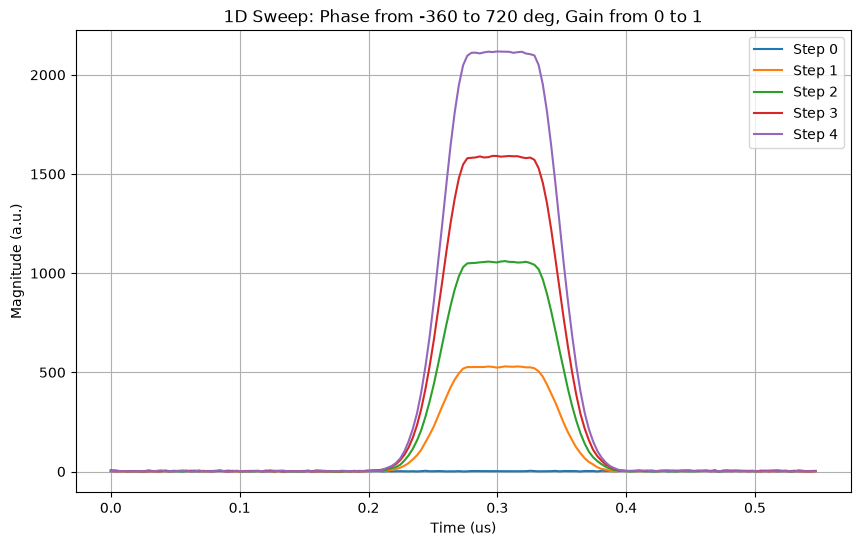

Swept phase values (degrees): [-360.  -90.  180.  450.  720.]
Swept gain values: [0.         0.24995422 0.49990844 0.74986266 0.99981688]


In [3]:
class SimpleSweepProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        # Define the loop that controls our sweep
        self.add_loop("my_sweep", self.cfg["steps"])

        # Define a Gaussian envelope for pulse shaping
        self.add_gauss(ch=gen_ch, name="ramp",
                       sigma=cfg['ramp_len']/10,
                       length=cfg['ramp_len'],
                       even_length=True)

        # Define the pulse with swept parameters
        self.add_pulse(ch=gen_ch, name="swept_pulse",
                       style="flat_top",
                       envelope="ramp",
                       freq=cfg['freq'],
                       length=cfg['flat_len'],
                       phase=QickSweep1D("my_sweep", -360, 720),  # Sweep from -360 to 720 deg
                       gain=QickSweep1D("my_sweep", 0.0, 1.0)      # Sweep gain from 0 to 1
                      )

        # Configure readout
        self.add_readoutconfig(ch=ro_ch, name="my_ro",
                               freq=cfg['freq'], gen_ch=gen_ch)
        self.send_readoutconfig(ch=ro_ch, name="my_ro", t=0)

    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="swept_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

# Configuration
config = {
    'steps': 5,                     # Number of sweep points
    'gen_ch': GEN_CH,
    'ro_ch': RO_CH,
    'freq': 100,                    # MHz
    'trig_time': 0.25,              # us
    'ro_len': 0.55,                 # us
    'flat_len': 0.05,               # us (flat segment duration)
    'ramp_len': 0.2                 # us (ramp duration)
}

# Run the sweep
prog = SimpleSweepProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

OUT = ARTIFACTS_ROOT / 'simple_sweep'
OUT.mkdir(parents=True, exist_ok=True)

# First simulation of the kernel session: build=True runs `make verilate`.
# It only needs to happen once per session -- see the PERFORMANCE NOTE in
# 00_intro_emu.ipynb for the build=False pattern used from here on.
soc = soc.prepare_emu(memdir=OUT, build=True)

iq_data = prog.acquire_decimated(soc, rounds=10)
time_axis = prog.get_time_axis(ro_index=0)

# Plot magnitude for each sweep step
plt.figure(figsize=(10, 6))
for i, iq_point in enumerate(iq_data[0]):
    plt.plot(time_axis, np.abs(iq_point.dot([1,1j])), label=f"Step {i}")
plt.legend()
plt.xlabel('Time (us)')
plt.ylabel('Magnitude (a.u.)')
plt.title('1D Sweep: Phase from -360 to 720 deg, Gain from 0 to 1')
plt.grid(True)
plt.show()

# Retrieve the actual swept values
phases = prog.get_pulse_param('swept_pulse', 'phase', as_array=True)
gains = prog.get_pulse_param('swept_pulse', 'gain', as_array=True)
print(f"Swept phase values (degrees): {phases}")
print(f"Swept gain values: {gains}")

**Explanation:**
- `add_loop("my_sweep", steps)` creates a loop. Any parameter wrapped in `QickSweep1D()` will vary across this loop.
- The tProc automatically:
  1. Updates the waveform parameters for each step
  2. Executes the `_body()` code
  3. Loops until all steps are complete
- `get_pulse_param()` returns the **actual** values after quantization, which may differ slightly from the requested values due to hardware precision limits.

## 4. 2D Sweeps with Nested Loops

For multi-dimensional scans, we can nest loops. The order of `add_loop()` calls determines the nesting order (first declared is outermost).

**Emulator note:** the on-hardware version of this cell uses `steps1=50, steps2=100, reps=100` (500,000 total shots). A Verilator simulation is much slower than real hardware, so we shrink this to `steps1=10, steps2=20, reps=1` to keep the run tractable while demonstrating the same pattern -- see [`00_intro_emu.ipynb`](../00_intro_emu.ipynb) for the same adaptation.

In [4]:
class Sweep2DProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        # Two nested loops: loop1 is outer, loop2 is inner
        self.add_loop("loop1", self.cfg["steps1"])
        self.add_loop("loop2", self.cfg["steps2"])

        # Define pulse with a 2D sweep
        self.add_gauss(ch=gen_ch, name="ramp",
                       sigma=cfg['ramp_len']/10,
                       length=cfg['ramp_len'],
                       even_length=True)

        self.add_pulse(ch=gen_ch, name="pulse_2d",
                       style="flat_top",
                       envelope="ramp",
                       freq=cfg['freq'],
                       length=cfg['flat_len'],
                       phase=cfg['phase'],
                       gain=cfg['gain'])

        # Configure readout
        self.add_readoutconfig(ch=ro_ch, name="my_ro",
                               freq=cfg['freq'], gen_ch=gen_ch)
        self.send_readoutconfig(ch=ro_ch, name="my_ro", t=0)

    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="pulse_2d", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

# 2D sweep: Gain varies in both loops
# HW version uses steps1=50, steps2=100, reps=100; shrunk for the emulator (see note above).
config_2d = {
    'steps1': 10,
    'steps2': 20,
    'gen_ch': GEN_CH,
    'ro_ch': RO_CH,
    'freq': 100,
    'trig_time': 0.25,
    'ro_len': 0.35,
    'flat_len': 0.05,
    'ramp_len': 0.2,
    'phase': 0,
    # Gain starts at 0.4. Increases by 0.5 in loop1, and by 0.1 in loop2
    'gain': 0.4 + QickSpan("loop1", 0.5) + QickSpan("loop2", 0.1)
}

prog = Sweep2DProgram(soccfg, reps=1, final_delay=1.0, cfg=config_2d)

OUT = ARTIFACTS_ROOT / 'sweep_2d'
OUT.mkdir(parents=True, exist_ok=True)
soc = soc.prepare_emu(memdir=OUT, build=False, test_run_ns=1_000_000)

iq_data = prog.acquire(soc, rounds=1)

# Get the actual gain values as a 2D array
gains_2d = prog.get_pulse_param('pulse_2d', 'gain', as_array=True)
print(f"Shape of gain grid: {gains_2d.shape}")
print(f"First row (first 10 values): {gains_2d[0, :10]}")
print(f"Last row (first 10 values): {gains_2d[-1, :10]}")

[sim] Running simulation with EMU_DIR=../../artifacts/02_parameter_sweeps/sweep_2d ...


Shape of gain grid: (10, 20)
First row (first 10 values): [0.39998779 0.40523714 0.41048648 0.41573582 0.42098517 0.42623451
 0.43148386 0.4367332  0.44198254 0.44723189]
Last row (first 10 values): [0.89989623 0.90514558 0.91039492 0.91564427 0.92089361 0.92614295
 0.9313923  0.93664164 0.94189098 0.94714033]


**Explanation of QickSpan:**
- `QickSpan(loop_name, increment)` adds an increment to a parameter each time the loop iterates
- The total parameter value is the sum of all spans across nested loops
- In this example, `gain = 0.4 + loop1_span + loop2_span`
- This creates a 2D grid where gain increases in both dimensions

**Loop order and data shape:**
- Data shape is `(reps, loop1, loop2, readout_length, I/Q)`
- The outermost loop (loop1) changes slowest

## 5. Sweeping Pulse Length

You can sweep any numeric parameter, including pulse lengths and delays.

[sim] Running simulation with EMU_DIR=../../artifacts/02_parameter_sweeps/length_sweep ...


[sim] Running simulation with EMU_DIR=../../artifacts/02_parameter_sweeps/length_sweep ...


[sim] Running simulation with EMU_DIR=../../artifacts/02_parameter_sweeps/length_sweep ...


[sim] Running simulation with EMU_DIR=../../artifacts/02_parameter_sweeps/length_sweep ...


[sim] Running simulation with EMU_DIR=../../artifacts/02_parameter_sweeps/length_sweep ...


...

[sim] Running simulation with EMU_DIR=../../artifacts/02_parameter_sweeps/length_sweep ...


[sim] Running simulation with EMU_DIR=../../artifacts/02_parameter_sweeps/length_sweep ...


[sim] Running simulation with EMU_DIR=../../artifacts/02_parameter_sweeps/length_sweep ...


[sim] Running simulation with EMU_DIR=../../artifacts/02_parameter_sweeps/length_sweep ...


Flat segment lengths (us): [0.05008013 0.07512019 0.10016026 0.12520032 0.15024038]
Total pulse lengths (us): [0.15024038 0.17528045 0.20032051 0.22536058 0.25040064]


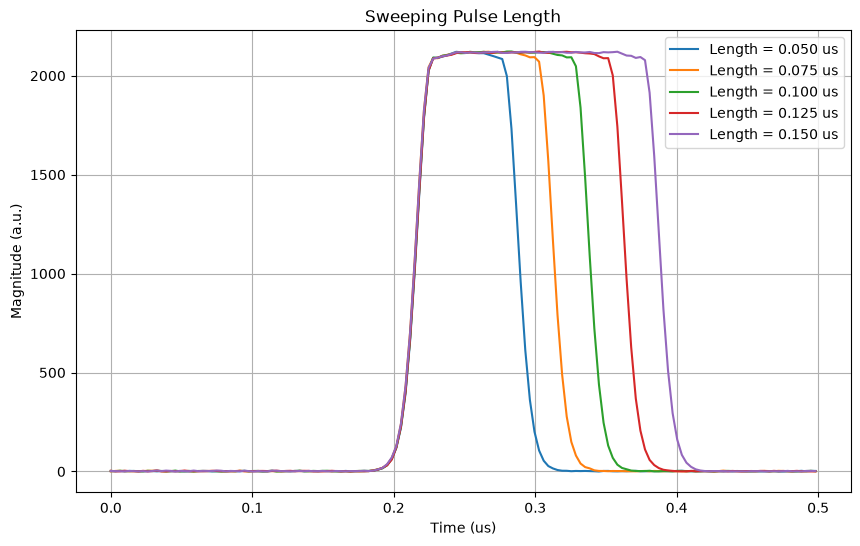

In [5]:
class LengthSweepProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop("length_sweep", self.cfg["steps"])

        # Gaussian envelope (fixed parameters)
        self.add_gauss(ch=gen_ch, name="ramp",
                       sigma=cfg['ramp_len']/10,
                       length=cfg['ramp_len'],
                       even_length=True)

        # Flat-top pulse with swept length
        self.add_pulse(ch=gen_ch, name="len_pulse",
                       style="flat_top",
                       envelope="ramp",
                       freq=cfg['freq'],
                       length=QickSweep1D("length_sweep", 0.05, 0.15),  # Sweep from 50ns to 150ns
                       phase=0,
                       gain=cfg['gain']
                      )

        self.add_readoutconfig(ch=ro_ch, name="my_ro",
                               freq=cfg['freq'], gen_ch=gen_ch)
        self.send_readoutconfig(ch=ro_ch, name="my_ro", t=0)

    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="len_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

# Configuration
config_len = {
    'steps': 5,
    'gen_ch': GEN_CH,
    'ro_ch': RO_CH,
    'freq': 100,
    'trig_time': 0.25,
    'ro_len': 0.5,
    'ramp_len': 0.1,
    'gain': 1.0
}

prog = LengthSweepProgram(soccfg, reps=1, final_delay=0.5, cfg=config_len)

OUT = ARTIFACTS_ROOT / 'length_sweep'
OUT.mkdir(parents=True, exist_ok=True)
soc = soc.prepare_emu(memdir=OUT, build=False)

iq_data = prog.acquire_decimated(soc, rounds=10)
time_axis = prog.get_time_axis(ro_index=0)

# Get the actual length values
lengths = prog.get_pulse_param('len_pulse', 'length', as_array=True)
total_lengths = prog.get_pulse_param('len_pulse', 'total_length', as_array=True)
print(f"Flat segment lengths (us): {lengths}")
print(f"Total pulse lengths (us): {total_lengths}")

# Plot results
plt.figure(figsize=(10, 6))
for i, iq_point in enumerate(iq_data[0]):
    plt.plot(time_axis, np.abs(iq_point.dot([1,1j])), label=f"Length = {lengths[i]:.3f} us")
plt.legend()
plt.xlabel('Time (us)')
plt.ylabel('Magnitude (a.u.)')
plt.title('Sweeping Pulse Length')
plt.grid(True)
plt.show()

**Note on pulse lengths:**
- `length` refers to the flat segment duration (for flat-top pulses)
- `total_length` includes the rise and fall times
- Both can be swept independently

## 6. Inspecting Sweep Parameters

You can list all available parameters for a pulse and retrieve their values.

In [6]:
# List all parameters for the pulse
print("Available parameters for 'len_pulse':")
print(prog.list_pulse_params('len_pulse'))

# Get all swept values as a dictionary
# This is useful for saving experiment metadata
swept_values = {}
for param in ['length', 'total_length', 'gain', 'phase', 'freq']:
    try:
        swept_values[param] = prog.get_pulse_param('len_pulse', param, as_array=True)
    except Exception:
        pass  # Parameter not swept or not available

print("\nSwept values:")
for param, values in swept_values.items():
    print(f"  {param}: {values}")

Available parameters for 'len_pulse':
['freq', 'phase', 'length', 'gain', 'total_length']

Swept values:
  length: [0.05008013 0.07512019 0.10016026 0.12520032 0.15024038]
  total_length: [0.15024038 0.17528045 0.20032051 0.22536058 0.25040064]
  gain: 1.0
  phase: 0.0
  freq: 99.99999961853027


## 7. Summary

You have learned:
- How to create 1D sweeps using `add_loop()` and `QickSweep1D`
- How to create 2D sweeps using nested loops and `QickSpan`
- How to sweep pulse lengths and other parameters
- How to retrieve the actual swept values using `get_pulse_param()`

**Key concepts:**
- Sweeps are executed entirely on the tProc (in simulation, entirely within one Verilator run), eliminating Python-FPGA/Python-simulator round trips
- Loop order determines the data shape (first declared = outermost)
- `QickSpan` allows building complex sweeps from simple components
- Always use `get_pulse_param()` to get the actual quantized values for accurate analysis
- On the emulator, keep sweep sizes (`steps` x `reps`) small -- simulated device time is real wall-clock time here

**Next steps:** Proceed to [`03_Advanced_Timing_emu.ipynb`](./03_Advanced_Timing_emu.ipynb) to learn about timeline management, `delay` vs `wait`, and avoiding timing pitfalls.